In [1]:
# sys.path.append('../..')
import importlib
import cisei_lib.geo_datasets.dem_utils as du
import cisei_lib.geo_datasets.gob_heights_utils as gh
importlib.reload(du)
importlib.reload(gh)

dem = 'dem-datasets'
dtm = f'{dem}/dtm/fabdem-dtm-parana'
dtm1 = f'{dem}/dtm/anadem-dtm-parana'
dsm = f'{dem}/dsm/copernicus-dsm-parana'
dsm1 = f'{dem}/dsm/aster-gdem-parana'
lulc = f'{dem}/lulc/esa-world-cover'
lulc1 = f'{dem}/lulc/esri-land-cover-2024'

ed_asa = -25.43188285765169, -49.27605438684823
pucpr = -25.451376951255053, -49.252777095141084
jd_botanico = -25.440793108803657, -49.237824902742794
museu = -25.409689697407796, -49.267060498223586
torre = -25.424018797077057, -49.29405137264106
ouro_fino = -24.996358655009765, -49.02705781638185
pico_marumbi = -25.44143390372285, -48.91460293567934
mirante = -25.47427673417167, -49.37857169050803 # passauna
passauna = -25.531417164785577, -49.38315688140852 # entrada
cabana = -25.501460412412808, -49.36641387345384 # passauna
haras = -25.49548204119312, -49.364266535708275 #passauna

parana_bounds = (-22.51, -54.62, -26.72, -48.02)

print('updated')
# %who 
# %whos  # List with details
# %reset -f  # Clear all variables (force)

ModuleNotFoundError: No module named 'cisei_lib.geo_datasets'

# Split DEM Datasets and Create Index

In [3]:
import cisei_lib.dem.dem_utils as du
import cisei_lib.dem.legacy.dem_sources as ds
import json;
import importlib
from pathlib import Path
importlib.reload(du)
importlib.reload(ds)

dem = Path('/home/einstein-bohr/Documents/PYTHON/dem-datasets')
print(dem.is_dir())

# SPLIT FUNCTIONS (only degree)
# esri = f'{dem}/lulc/annual-lulc-2023'
# du.split_geotiff_to_degree_tiles(f'{esri}/22K_20230101-20240101.tif', lulc2, f'{lulc2}/index-geo.json')
# du.create_global_tile_index(lulc2, f'{lulc2}/index-geo.json')
# print(du.find_tile_by_coord( f'{dtm}/index-geo.json',*start))
# du.move_tiles_outside_bounds(f'{lulc2}/index-geo.json', *parana_bounds, lulc2, 'esri-land-cover-extra2')

# MERGE
# du.merge_geotiffs( merge_list, 'teste.tif')
# du.visualize_tiff('teste.tif')

cur_dir = Path.cwd().parent
src_dir = cur_dir / 'esri-land-2023-2024'
dst_dir = cur_dir / 'esri-land-2024-utm'
# SPLIT FUNCTION (UTM)
# du.create_geotiff_index_new_v2(src_dir, src_dir / 'test3-geo.json')
# ds.split_geotiff_to_utm_tiles(src_dir / '22K_20230101-20240101.tif', dst_dir)
# du.create_geotiff_index_new_v2(dst_dir, dst_dir / 'index-geo.json')
# ds.move_tiles_outside_roi_native(dst_dir / 'index-geo.json', dst_dir, cur_dir / 'esri_land_2023_extra', ds.PR_WGS84_BBOX)
# du.create_geotiff_index_new_v2(dst_dir, dst_dir / 'index-geo.json')
cur_dir.is_dir()


False


True

# Explore DEM Datasets

## Find Path Profiles

S026W050_FABDEM_V1-2.tif
EPSG:4326
['S026W050_FABDEM_V1-2.tif']
['s25_w050.tif', 's26_w049.tif']
2


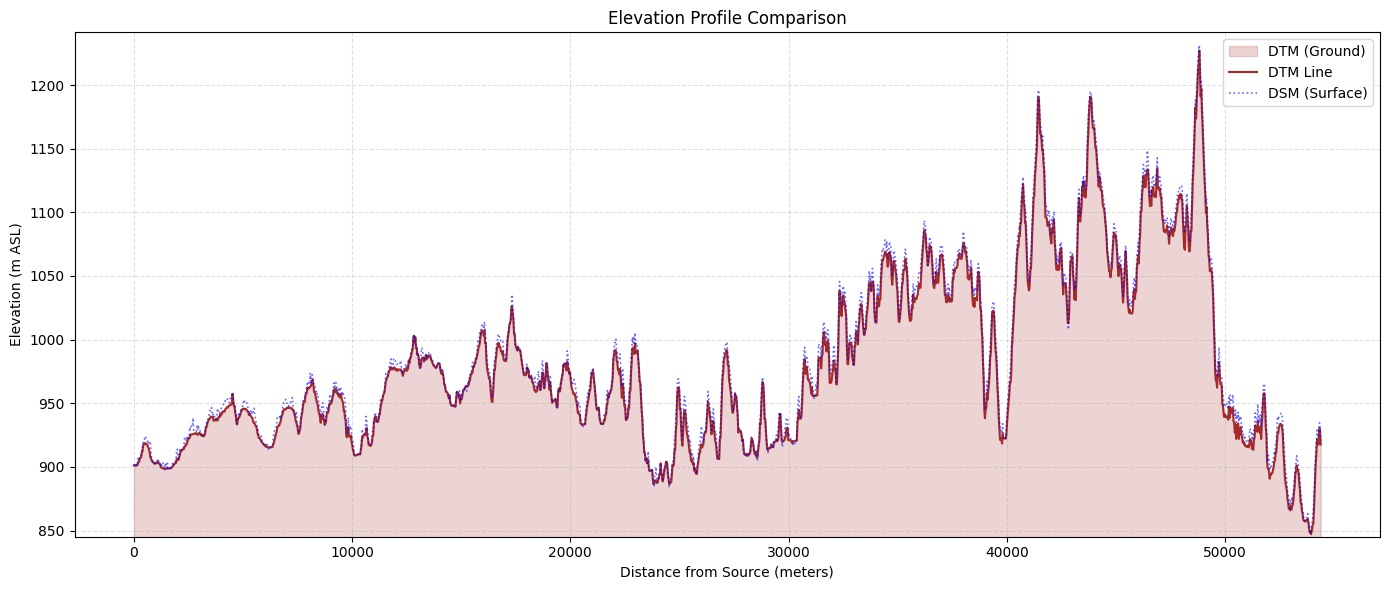

In [53]:
#res = du.find_tile_by_coord(f'{dtm}/index-geo.json', *ed_asa)
print(res['id_filename'])
print(res['crs_native'])
#res1 = du.find_tiles_by_list(f'{dtm}/index-geo.json', [ed_asa,pucpr])
print(res1)
#res2 = du.get_path_data_from_tiff(f'{dtm}/{res1[0]}', res['crs_native'], ed_asa, pucpr)
#du.plot_combined_profiles(res2)
print(du.find_tiles_by_list(f'{dtm1}/index-geo.json', [ouro_fino, pico_marumbi]))
print(len(du.find_tiles_by_path(f'{dtm1}/index-geo.json', ed_asa, ouro_fino))) 
res3 = du.get_path_data_from_index(f'{dtm}/index-geo.json', ed_asa, ouro_fino)
res4 = du.get_path_data_from_index(f'{dtm1}/index-geo.json', ed_asa, ouro_fino)
res5 = du.get_path_data_from_index(f'{dsm}/index-geo.json', ed_asa, ouro_fino)
du.plot_combined_profiles(res3, res5) 


## Plot Combine Profiles

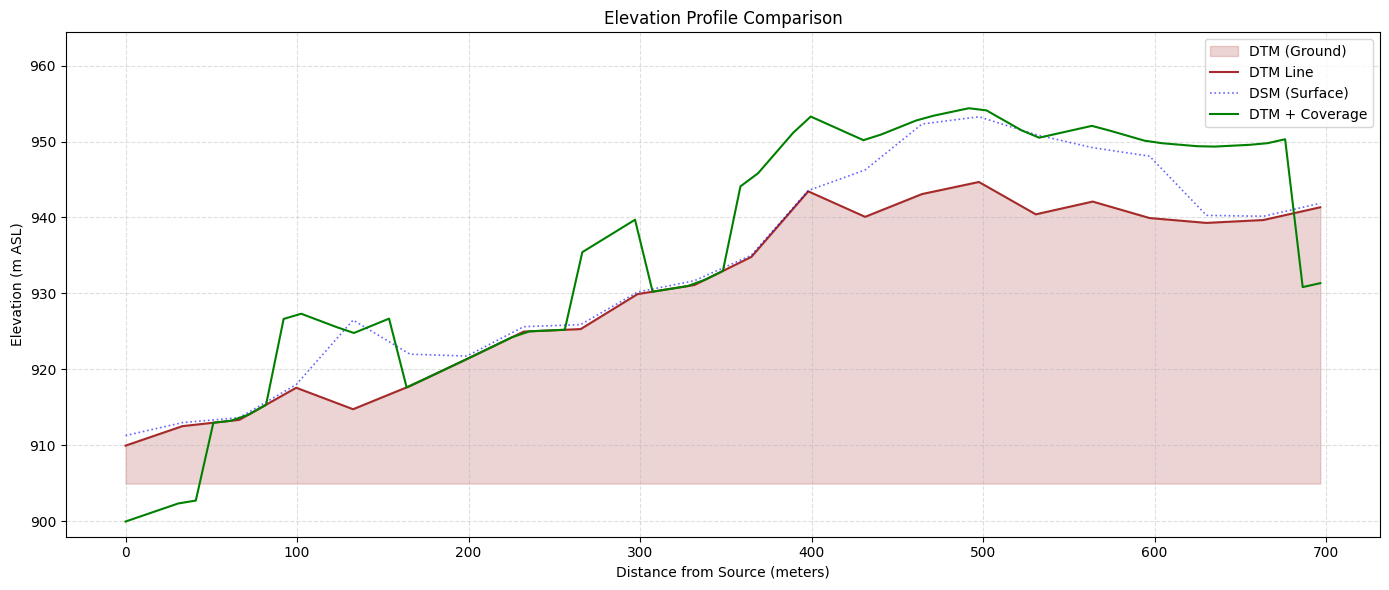

In [205]:
import json
f = lambda x: f'{x}/index-geo.json'
f1 = lambda x: json.loads(open(f'{x}/cover-legend.json').read())
res_dtm = du.get_path_data_from_index(f(dtm), cabana, haras)    
res_dsm = du.get_path_data_from_index(f(dsm), cabana, haras)
res_lulc = du.get_path_data_from_index(f(lulc), cabana, haras)
x = {v['name']:k for k,v in f1(lulc).items()}
lulc_h = {int(x['tree_cover']):10, int(x['built_up']):-10}
#du.plot_combined_profiles(res_dtm, res_dsm, res_lulc, lulc_h)
res_lulc = du.get_path_data_from_index(f(lulc2), cabana, haras)
x = {v['name']:k for k,v in f1(lulc2).items()}
lulc_h = {int(x['tree_cover']):10, int(x['built_up']):-10}
du.plot_combined_profiles(res_dtm, res_dsm, res_lulc, lulc_h)
res = du.get_high_res_tree_profile(cabana, haras, res_lulc, f1(lulc2))

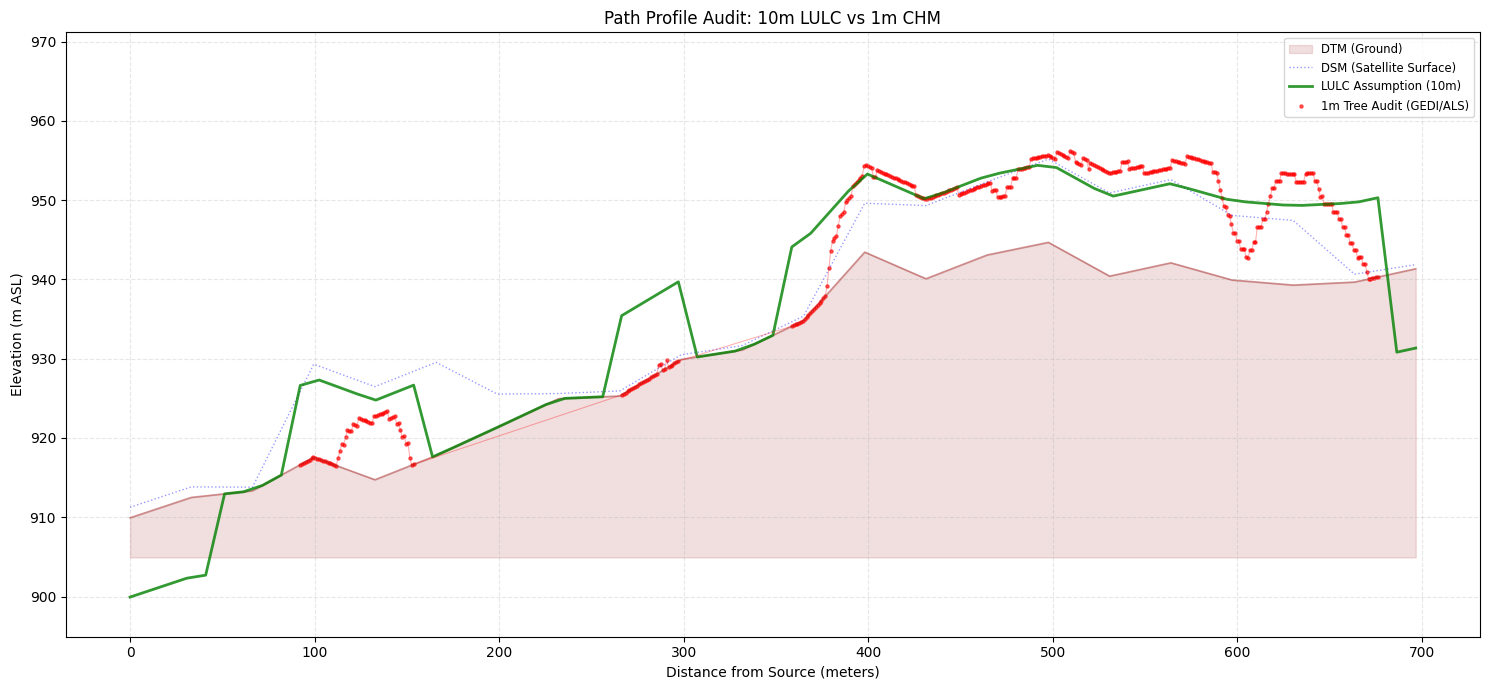

In [206]:
res_dsm2 = du.apply_sharpened_canopy_tuples(res_dsm, res_dtm, 2)
du.plot_advanced_profiles(res_dtm, res_dsm2, res_lulc, lulc_h, res)

## TEST COVERAGE

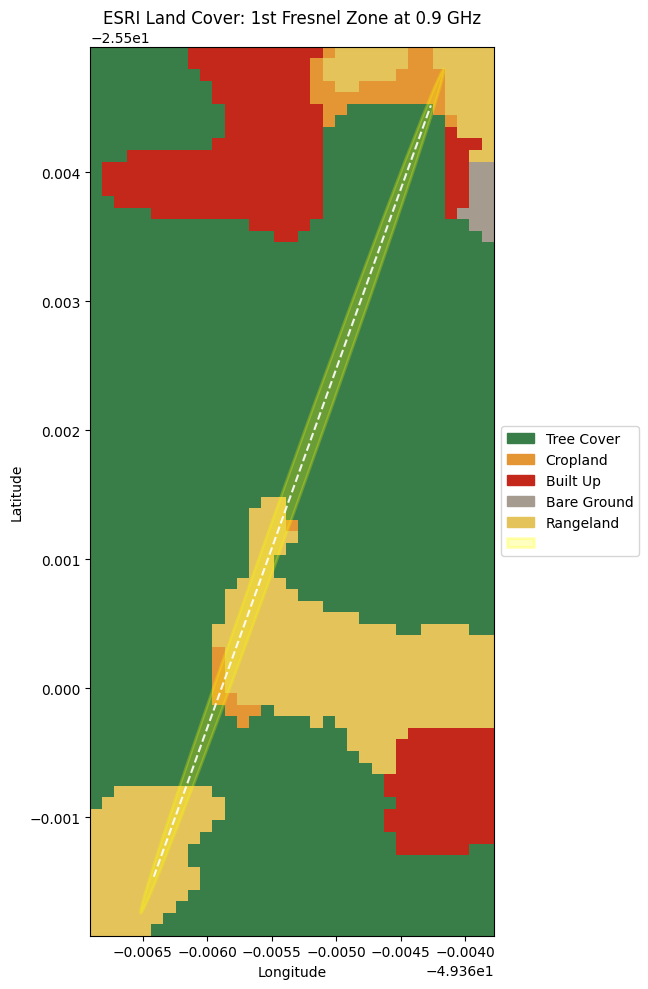

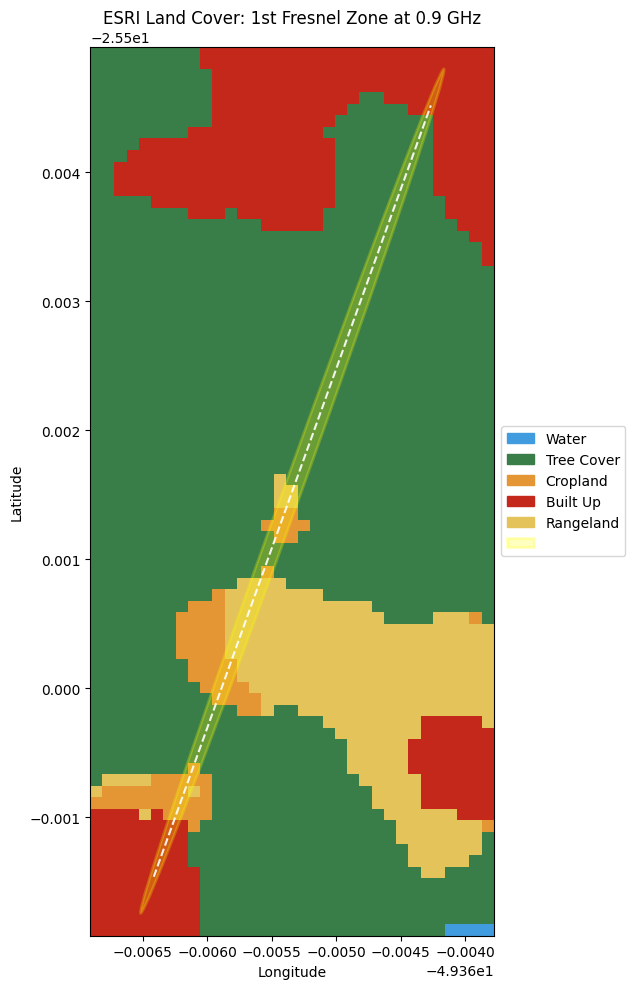

In [204]:
f = lambda x: f'{x}/index-geo.json'
f1 = lambda x: f'{x}/cover-legend.json'
du.show_lulc_fresnel_zone(f(lulc1), f1(lulc1), cabana, haras, 0.9, margin_px=5)  
du.show_lulc_fresnel_zone(f(lulc2), f1(lulc2), cabana, haras, 0.9, margin_px=5)  

In [151]:
importlib.reload(du)
lat, lon = -25.497452152540774, -49.3679729858833
# qk = du.get_quadkey(lat, lon, 10)
ch = du.get_canopy_height_at_point(lat, lon)
print(ch)

p = [ (-25.4974, -49.36797), (-25.49741, -49.367971), (-25.49742, -49.367972),(-25.49743, -49.367973),(-25.49744, -49.367974), 
     (-25.498206672325953, -49.36521167644122), (-25.502445944525807, -49.36435009582304), (-25.5015584825736, -49.36628197983164)]
du.audit_tree_segments(p)


11.0


{(-25.4974, -49.36797): 11.0,
 (-25.49741, -49.367971): 11.0,
 (-25.49742, -49.367972): 11.0,
 (-25.49743, -49.367973): 11.0,
 (-25.49744, -49.367974): 11.0,
 (-25.498206672325953, -49.36521167644122): 5.0,
 (-25.502445944525807, -49.36435009582304): 0.0,
 (-25.5015584825736, -49.36628197983164): 0.0}